In this notebook you will learn how to download satellite images from Sentinel Hub.

# Imports

> ***GeoPandas*** - to make working with geospatial data in Python easier. It combines the capabilities of Pandas and Shapely, providing geospatial operations in Pandas and a high-level interface to multiple geometries to Shapely.



*   Read more: https://geopandas.org/en/stable/getting_started/introduction.html





> The ***sentinelhub*** Python package is the official Python interface for Sentinel Hub services. It supports most of the services described in the Sentinel Hub documentation and any type of satellite data collections, including Sentinel, Landsat, MODIS, DEM, and custom collections produced by users.



*   Read more: https://sentinelhub-py.readthedocs.io/en/latest/index.html#

In [7]:
# !pip install sentinelhub

In [6]:
import datetime
import numpy as np
import pandas as pd
import geopandas as gpd
import matplotlib.pyplot as plt

import rasterio
import rasterio.mask as rio_mask

# get the specific sentinel hub functions we need
from sentinelhub import WmsRequest, WcsRequest, MimeType, BBox, CRS, DataCollection, SHConfig
from sentinelhub.geo_utils import bbox_to_dimensions

# Prepare data pre-processing functions

## Data download

**Sentinel-1**

> The Sentinel-1 mission includes C-band imaging operating in four exclusive imaging modes with different resolution (down to 5 m) and coverage (up to 400 km). It provides dual polarisation capability, very short revisit times and rapid product delivery. For each observation, precise measurements of spacecraft position and attitude are available.
>
> Synthetic Aperture Radar (SAR) has the advantage of operating at wavelengths not impeded by cloud cover or a lack of illumination and can acquire data over a site during day or night time under all weather conditions. Sentinel-1, with its C-SAR instrument, can offer reliable, repeated wide area monitoring.
>
>Read more: https://sentinel.esa.int/web/sentinel/missions/sentinel-1

**Sentinel-2A**

> SENTINEL-2 is a European wide-swath, high-resolution, multi-spectral imaging mission. The full mission specification of the twin satellites flying in the same orbit but phased at 180°, is designed to give a high revisit frequency of 5 days at the Equator.
>
>SENTINEL-2 carries an optical instrument payload that samples 13 spectral bands: four bands at 10 m, six bands at 20 m and three bands at 60 m spatial resolution. The orbital swath width is 290 km.
>
>Read more: https://sentinel.esa.int/web/sentinel/missions/sentinel-2


In [9]:
def get_sentinelhub_imagery_l2a(time_interval, box, instance_id, band, maxcc=1.0):
    """
    This function will collect L2A processed satellite images from sentinelhub over the given area and given time interval or date

    Parameters
    ----------
    time_interval : list
        A list of two date time objects with the period over which to get data
    box : list of tuples
        The coordinate pairs for the top left and bottom right of the bounding box of the image to be downloaded
    instance_id : string
        The sentinel hub instance ID to collect images with
    band : string
        The bands to download from sentinelhub according to the evaluation script in the sentinelhub configurator
    maxcc : float (optional)
        Maximum cloud coverage of a tile. Defaults to 1.0

    Returns
    -------
    data : list
        A list of numpy.array() objects each of which is the image pixel information in float format
    bounding_box : sentinelhub bounding box object
        The bounding box object from sentinelhub that describes the polygon around the image
    dates : list
        A list of datetime objects corresponding to when each image was captured

    """

    # collect configuration from config.json file   
    sentinelhub_config = SHConfig()
    sentinelhub_config.instance_id = instance_id

    # our bounding box around the area
    bounding_box = BBox(bbox=box, crs=CRS(4326))
    
    # convert the area to width * height format with spacial resolution equals 10m
    width, height = bbox_to_dimensions(bounding_box, 10)
    
    # request the Sentinel-2 images
    wms_request = WmsRequest(data_collection=DataCollection.SENTINEL2_L2A,
                             layer=band,
                             bbox=bounding_box,
                             time=(time_interval[0], time_interval[1]),
                             width=width, 
                             height=height,
                             image_format=MimeType.TIFF,
                             config=sentinelhub_config,
                             maxcc=maxcc)
   
    # get the dates
    dates = wms_request.get_dates()
    
    # get and return the data
    return wms_request.get_data(), bounding_box, dates

### Cloud detection

On some images the area of interest may be covered with clouds. We need to filter them and get ones with cloud coverage below the threshold.

In [10]:
def cloud_detection_l2a(images, dates):
    """
    This function will filter out cloudy images given a list of images and dates, it uses NDSI as a measure of cloud and calculates thresholds of cloud

    Parameters
    ----------
    images : list of arrays
        this is a list of the images which have come straight from sentinel hub
    dates : list
        a list of the dates that correspond to the capture date of each image in the images list

    Returns
    -------
    final_cloud_free_images : list
        a list containing just the images which are below the cloud free threshold
    final_cloud_free_dates : list
        a list of dates corresponding to the cloud free images
    """
    
    # initialise empty arrays to store the cloud free images, the dates and the percentage of clouds in each image
    initial_cloud_free_images = []
    initial_cloud_free_dates = []
    cloud_percentages = []
    
    # first iterate through all images and cut off at 10%
    for i in range(0, len(images)):
        # calculate the current ndsi from the respective imagery bands
        current_ndsi = (images[i][:, :, 2] - images[i][:, :, 10]) / (images[i][:, :, 2] + images[i][:, :, 10])
        # remove empty images or images with corrupted pixels
        if np.std(current_ndsi) == 0.0 or np.isnan(np.mean(current_ndsi)) or len(current_ndsi[current_ndsi == 0.0]) > 20:
            print('Empty Image')
            continue
        # only if the images are bellow 15% put them in the initial lists
        if (len(current_ndsi[current_ndsi > -0.25]) / len(current_ndsi.flatten())) * 100 < 15:
            initial_cloud_free_images.append(images[i])
            initial_cloud_free_dates.append(dates[i])
            # calculate the cloud cover percentage
            cloud_percentages.append(len(current_ndsi[current_ndsi > -0.25]) / len(current_ndsi.flatten()) * 100)
    # convert to a numpy array for more efficient use and computations
    cloud_percentages = np.array(cloud_percentages)
    standard_error = cloud_percentages.std()
    mean_cloud_cover = cloud_percentages.mean()

    # calculate a threshold by using the mean of all bellow 10% and then 1.5* the standard error
    threshold = mean_cloud_cover + 1.5 * standard_error
    # threshold = mean_cloud_cover + 3 * standard_error
    if threshold < 1.0:
        threshold = 3.0
    print('Cloud Threshold is', threshold)
    # set up final image and date arrays
    final_cloud_free_images = []
    final_cloud_free_dates = []
    # loop through the initially sorted images and remove any above the threshold
    for i in range(0, len(initial_cloud_free_images)):
        current_ndsi = (initial_cloud_free_images[i][:, :, 2] - initial_cloud_free_images[i][:, :, 10]) / (initial_cloud_free_images[i][:, :, 2] + initial_cloud_free_images[i][:, :, 10])
        print((len(current_ndsi[current_ndsi > -0.25])/ len(current_ndsi.flatten())) * 100)
        if (len(current_ndsi[current_ndsi > -0.25])/ len(current_ndsi.flatten())) * 100 < threshold:
            final_cloud_free_images.append(initial_cloud_free_images[i])
            final_cloud_free_dates.append(initial_cloud_free_dates[i])
    
    return final_cloud_free_images, final_cloud_free_dates

## Calculate bounding box coordinates from geojson

To download an image from Sentinel Hub you need the top left and bottom right coordinates of a bounding box covering the area of interest. 
To get them, use the following function.

In [11]:
def calculate_bounds_from_geojson(geojson):
    """
    This function calculates the top left and bottom right coordinates of a box around a geojson used for downloading imagery

    Parameters
    ----------
    geojson : dict
        the geojson that describes the spatial information of the farm / area in question.

    Returns
    -------
    bounds : list
        list of tuples that corresponds to lat and long of top left and bottom right coordinates.

    """
    geojson_as_dataframe = gpd.GeoDataFrame.from_features(geojson)
    bounds = [(geojson_as_dataframe.total_bounds[0], geojson_as_dataframe.total_bounds[1]), (geojson_as_dataframe.total_bounds[2], geojson_as_dataframe.total_bounds[3])]
    
    return bounds

# Download imagery from Sentinel-2 and crop the area of interest with geojson

## Define input parameters

Read geojson file and calculate bounds of area of interest

In [12]:
# geojson file of a test area

# lets have a look at park Guell in Barcelona
geojson = {
    "type": "FeatureCollection",
    "name": "park_Guell",
    "crs": {
        "type": "name",
        "properties": {"name": "urn:ogc:def:crs:OGC:1.3:CRS84"}
        },
    "features": [{
        "type": "Feature",
        "properties": {"id": 4},
        "geometry": {
            "type": "Polygon",
            "coordinates": [[[2.1500, 41.4162], [2.1540, 41.4158], [2.1545, 41.4135], [2.1525, 41.4125], [2.1495, 41.4132], [2.1485, 41.4148], [2.1500, 41.4162]]]
            }
        }
    ]
}

In [13]:
box = calculate_bounds_from_geojson(geojson)
box

[(np.float64(2.1485), np.float64(41.4125)),
 (np.float64(2.1545), np.float64(41.4162))]

## Download Sentinel-2 data

You can find your instance ID on the portal where you registered to download the Sentinel-2 data, e.g. [Planet/Sentinel-Hub](https://insights.planet.com/sign-up) or [Copernicus](https://dataspace.copernicus.eu/analyse/apis).

In [31]:
# get the images
data, bbox, dates = get_sentinelhub_imagery_l2a([datetime.datetime.strptime("2022/05/01",'%Y/%m/%d'),
                        datetime.datetime.strptime("2022/05/20",'%Y/%m/%d')],
                        box,
                        'XXXXXXXXXXXXXXXXXXXXXX',### INSERT YOUR INSTANCE ID HERE ### ,
                        'ALLBANDSFLOAT',
                        maxcc=0.9)

In [32]:
## dates of all images we got
dates

[datetime.datetime(2022, 5, 2, 10, 49, 35),
 datetime.datetime(2022, 5, 7, 10, 49, 45),
 datetime.datetime(2022, 5, 12, 10, 49, 39),
 datetime.datetime(2022, 5, 17, 10, 49, 46)]

In [16]:
# shape of the last image
data[-1].shape

(41, 51, 12)

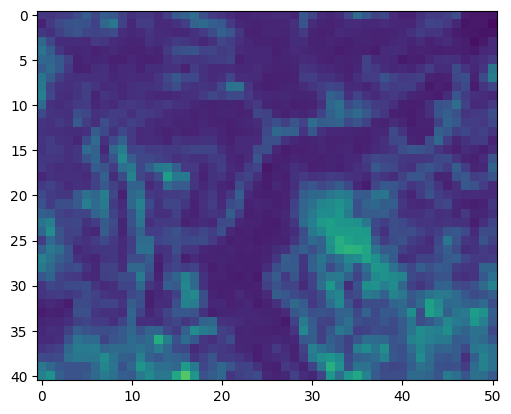

In [17]:
# plot the last image we have
plt.imshow(data[-1][:,:,1], vmin=0, vmax=0.3)

In [18]:
# perform cloud detection
cloud_free_images, cloud_free_dates = cloud_detection_l2a(data, dates)

Cloud Threshold is 6.826877092300336
6.791009086561455
6.647537063605931


In [19]:
# how many cloud free images do we have? and when were they taken?
len(cloud_free_images), cloud_free_dates

(2,
 [datetime.datetime(2022, 5, 12, 10, 49, 39),
  datetime.datetime(2022, 5, 17, 10, 49, 46)])

(41, 51, 12)


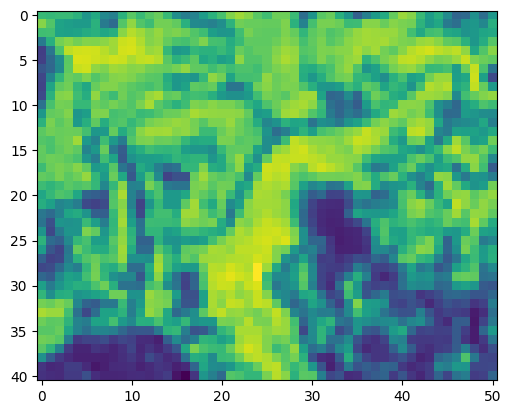

In [20]:
print(cloud_free_images[-1].shape)

# plot the NDVI of the last cloud free image (Normalized Difference Vegetation Index = (band_8 - band_4)/(band_8 + band_4))
image = cloud_free_images[-1]
plt.imshow((image[:, :, 7] - image[:, :, 3]) / (image[:, :, 7] + image[:, :, 3]))

## Mask the satellite image

In [21]:
def generate_masks_geojson_inmemory(image: np.ndarray, bbox: BBox, geojson) -> dict:
    """
    Creates masks dictionary from geojson structure, using bbox for mask dimensions and image for num channels.

    Parameters
    ----------
    image : numpy array
        Image is used to get the number of channels for the masks
    bbox : BBox, List, or Tuple
        BBox or bounds. Used to get the dimensions of the masks
    geojson : dict
        the dictionary that describes the spatial information of the area

    Returns
    ----------
    out_mask : numpy array
        array of values [1 or np.nan]
    """

    # Get bbox dimensions
    bbox = BBox(bbox=bbox, crs=CRS(4326))  # 4326 is the ESPG code for WGS84
    width, height = bbox_to_dimensions(bbox, 10)

    n_channels = image.shape[2]

    transform = rasterio.transform.from_bounds(*rasterio.coords.BoundingBox(*bbox.lower_left, *bbox.upper_right),
                                               height=height,
                                               width=width)

    # create a list of geometries as rasterio expects it
    geometries = [feature["geometry"] for feature in geojson["features"]]

    with rasterio.io.MemoryFile() as memfile:
        with memfile.open(driver='GTiff', count=n_channels, height=height, width=width, dtype=np.float64,
                          nodata=float('nan'), transform=transform, crs='EPSG:4326') as f:
            f.write(np.moveaxis(image, 2, 0).astype(np.float64))  # move the channels to the first axis for rasterio

        with memfile.open() as current_raster:
            # generate the mask using rasterio's inbuilt functionality
            out_mask, out_transform_ = rio_mask.mask(current_raster,
                                                            geometries,
                                                            crop=False)
            out_mask[~np.isnan(out_mask)] = 1  # set non nan values to 1

    return out_mask

In [22]:
mask = generate_masks_geojson_inmemory(cloud_free_images[-1], bbox, geojson)

/Users/nataliaefremova/miniforge3/envs/cloudcasting311/lib/python3.11/site-packages/sentinelhub/geometry.py:137: SHDeprecationWarning: Initializing `BBox` objects from `BBox` objects will no longer be possible in future versions.
  return cls._tuple_from_bbox(bbox)


In [23]:
mask.shape

(12, 41, 51)

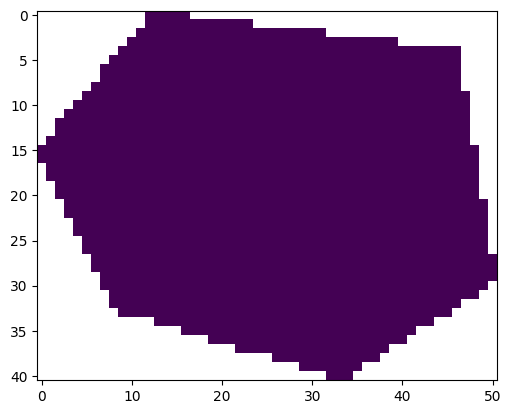

In [24]:
plt.imshow(mask[0,:,:])

In [25]:
# check shapes of the image and the mask before masking
print(f"Image shape: {image.shape}")
print(f"Mask shape: {mask.shape}")

Image shape: (41, 51, 12)
Mask shape: (12, 41, 51)


In [26]:
# move mask channels to the back
mask_channels_last = np.moveaxis(mask, 0, 2)  # (C, H, W) -> (H, W, C)
# mask the image
masked_img = image * mask_channels_last

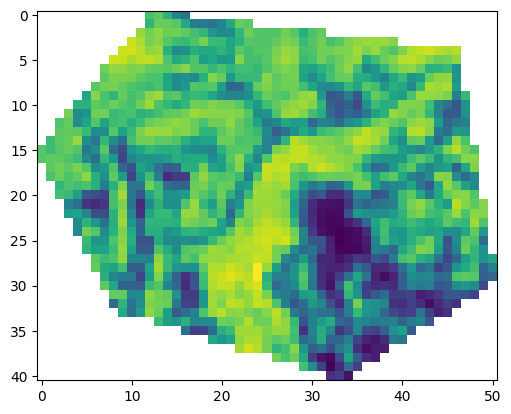

In [27]:
# plot the NDVI of the masked image
plt.imshow((masked_img[:, :, 7] - masked_img[:, :, 3]) / (masked_img[:, :, 7] + masked_img[:, :, 3]))

## Save a satellite image as a raster

In [28]:
def convert_to_raster(array, coordinates, file_name):
    """
    Parameters
    ----------
    array : numpy.array()
        array of the image
    coordinates : list of tuples
        list of corner coordinates of the image
    file_name : string
        the name of the output file

    Returns
    -------
    None

    """
    # get a shape of a new raster
    array = np.moveaxis(array, 2, 0)
    dst_shape = array.shape

    box = BBox(bbox=coordinates, crs=CRS(4326))
    # extract the bounds from our bounding box and use this to create a transformation

    dst_transform = rasterio.transform.from_bounds(*rasterio.coords.BoundingBox(*box.lower_left, *box.upper_right), width=dst_shape[2], height=dst_shape[1])

    # Write it out to a file.
    with rasterio.open(file_name, 'w', driver='GTiff',
                                  width=dst_shape[2], height=dst_shape[1],
                                  count=dst_shape[0], dtype=np.float64, nodata=float('nan'),
                                  transform=dst_transform, crs='EPSG:4326') as dst:
        dst.write(array.astype(np.float64))

In [ ]:
file_path = 'path-to-your-data/'  # change a directory to your folder
full_file_name = file_path + 'park_Guell_masked.tif'

convert_to_raster(masked_img, bbox, full_file_name)